# Домашнее задание 8: Face Recognition и Image Retrieval

В этом домашнем задании поработаем с датасетом Friends — https://www.kaggle.com/datasets/amiralikalbasi/images-of-friends-character-for-face-recognition/data — и с помощью библиотеки InsightFace реализуем простую систему распознавания лиц. План работы:
1. Посчитаем датасет и представим его в удобном формате.
2. Реализуем функцию для детектирования лиц и извлечения эмбеддингов.
3. Визуализируем результаты.
4. Реализуем функцию для вычисления схожести лиц.
5. Реализуем систему поиска человека на групповом фото.
6. Реализуем функцию для подсчёта метрики mAP.

In [2]:
# для чекера важно ставить старую версию
%pip install insightface==0.7.3 onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.3 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 79.8 MB/s eta 0:00:00:00:0100:01
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1078147 sha256=ee380387248560c9af35f7fb3cea4b4bd8d5aa94d3bc22245f69a4f25bd67828
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
from collections import defaultdict
from pathlib import Path

import insightface
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

### Задание 1: Работа с датасетом

В качестве первого задания по традиции реализуем функцию для работы с датасетом. Напишите функцию, которая вернёт DataFrame, каждый ряд которого содержит имя человека, путь к фотографии, bounding box и эмбеддинг. Последние два столбца пока оставим пустыми и заполним в следующих заданиях. Пока загрузите только train-часть датасета.

In [ ]:
def create_face_dataset(root_dir: str = 'dataset') -> pd.DataFrame:
    path = Path(root_dir) / "Train"
    
    folders = path.iterdir()
    data = []

    for folder in folders:
        label = folder.stem
        files = folder.glob("[a-zA-Z]*")
        
        for file in files:
            data.append([label, str(file), None, None])
    
    df = pd.DataFrame(data, columns=["person_name", "path", "bboxes", "embeddings"])
    return df

dir_path = "/kaggle/input/datasets/amiralikalbasi/images-of-friends-character-for-face-recognition/Friends" # путь к данным
dataset = create_face_dataset(dir_path)
dataset.head()

In [5]:
# решение автора
def create_face_dataset(root_dir: str = 'dataset') -> pd.DataFrame:
    data = []
    
    # Walk through dataset directory structure
    for mode in os.listdir(root_dir):
        if mode != 'Test':
            mode_dir = os.path.join(root_dir, mode)
            for person_name in os.listdir(mode_dir):
                person_dir = os.path.join(mode_dir, person_name)
                for photo_name in os.listdir(person_dir):
                    if photo_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        data.append({
                            'person_name': person_name,
                            'path': os.path.join(person_dir, photo_name),
                            'bboxes': None,
                            'embeddings': None
                        })
    
    return pd.DataFrame(data)

dir_path = "/kaggle/input/datasets/amiralikalbasi/images-of-friends-character-for-face-recognition/Friends" # путь к данным
dataset = create_face_dataset(dir_path)
dataset.head()

,person_name,path,bboxes,embeddings
0,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,None,None
1,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,None,None
2,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,None,None
3,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,None,None
4,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,None,None


### Задание 2: Нахождение лиц и извлечение эмбеддингов

В этом задании реализуем функцию, которая будет детектировать лица на изображении и извлекать их эмбеддинги, для этого воспользуемся библиотекой InsightFace. Функция должна принимать на вход путь к изображению и модель InsightFace, а возвращать словарь с эмбеддингами и bounding box. Обратите внимание, что метод get модели ожидает BGR-изображение.

In [ ]:
print(insightface.__version__)  # должно быть 0.7.3

In [8]:
# model = insightface.app.FaceAnalysis(providers=['CPUExecutionProvider', 'CUDAExecutionProvider'])
# model.prepare(ctx_id=0)

model = insightface.app.FaceAnalysis(
    name='buffalo_l',
    providers=['CPUExecutionProvider']
)

model.prepare(ctx_id=-1, det_size=(640, 640))

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 95640.02KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [ ]:
def extract_face_embeddings(model: insightface.app.FaceAnalysis, image_path: str) -> dict[str, list[np.ndarray]]:
    img = cv2.imread(image_path)
    faces = model.get(img)
    ans = {"embeddings": [], "bboxes": []}
    
    if not faces:
        return ans
    
    for face in faces:
        ans["embeddings"].append(face["embedding"])
        ans["bboxes"].append(face["bbox"])
    
    return ans

In [ ]:
# фильтрация боксов
def extract_face_embeddings(model, image_path):
    img = cv2.imread(image_path)
    faces = model.get(img)

    if not faces:
        return {"embeddings": None, "bboxes": None}

    # выбрать самое крупное лицо
    face = max(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
    )

    return {
        "embeddings": face.embedding,
        "bboxes": face.bbox.astype(np.int32)
    }

In [6]:
# решение автора
def extract_face_embeddings(model: insightface.app.FaceAnalysis, image_path: str) -> dict[str, list[np.ndarray]]:
    annotations = defaultdict(list)

    #read image
    image = cv2.imread(image_path)
    
    # Detect faces in image
    faces = model.get(image)
    
    # Extract embeddings for each detected face
    for face in faces:
        if hasattr(face, 'embedding'):
            annotations['embeddings'].append(face.embedding)
            annotations['bboxes'].append(face.bbox.astype(np.int32))
            
    return annotations

Отлично, теперь мы можем извлечь эмбеддинги и bounding box для каждого изображения в датасете.

In [9]:
annotations = dataset.apply(lambda row: extract_face_embeddings(model, row['path']), axis=1)

dataset['embeddings'] = annotations.apply(lambda x: x['embeddings'])
dataset['bboxes'] = annotations.apply(lambda x: x['bboxes'])

dataset.head()

,person_name,path,bboxes,embeddings
0,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[151, 18, 209, 100]]","[[0.27970353, 0.51977813, 0.9611456, 0.3207544..."
1,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[187, 94, 356, 335]]","[[-0.2987133, 1.731902, 0.20625849, 0.8639137,..."
2,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[127, 108, 287, 329]]","[[-0.047899358, 1.9557377, 1.1305449, 1.558615..."
3,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[311, 59, 421, 231], [87, 253, 154, 340]]","[[-0.93809015, 1.194003, 1.0337229, 0.4990284,..."
4,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[88, 42, 171, 158]]","[[-0.05424091, 1.2234596, 0.8004323, 0.5582210..."


Дропнем строки с пустыми эмбеддингами и bounding box, т. к. некоторые изображения сняты очень близко и лицо не детектируется.

In [10]:
dataset = dataset[(dataset['embeddings'].str.len() > 0) & (dataset['bboxes'].str.len() > 0)]
dataset.head()

,person_name,path,bboxes,embeddings
0,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[151, 18, 209, 100]]","[[0.27970353, 0.51977813, 0.9611456, 0.3207544..."
1,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[187, 94, 356, 335]]","[[-0.2987133, 1.731902, 0.20625849, 0.8639137,..."
2,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[127, 108, 287, 329]]","[[-0.047899358, 1.9557377, 1.1305449, 1.558615..."
3,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[311, 59, 421, 231], [87, 253, 154, 340]]","[[-0.93809015, 1.194003, 1.0337229, 0.4990284,..."
4,Phoebe,/kaggle/input/datasets/amiralikalbasi/images-o...,"[[88, 42, 171, 158]]","[[-0.05424091, 1.2234596, 0.8004323, 0.5582210..."


In [11]:
len(dataset)

296

In [ ]:
dataset.to_parquet("train_meta.parquet", index=False)

Загрузите метаданные датасета в LMS.

### Задание 3: Визуализация лиц


Подготовимся к последующим заданиям, напишем функцию для визуализации лиц. Она должна принимать на вход путь к изображению, bounding box и лейбл, а возвращать изображение с нарисованными bounding box. Также функция должна выводить изображение с помощью matplotlib.

In [ ]:
def visualize_faces(image_path: str, bboxes: list[np.ndarray], labels: list[str]) -> np.ndarray:
    img = cv2.imread(image_path)
    color = (0, 0, 255)
    for box in bboxes:
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 2)
    plt.imshow(img[:,:,::-1])
    return img

In [ ]:
sample = visualize_faces(dataset.iloc[0]['path'], dataset.iloc[0]['bboxes'], [dataset.iloc[0]['person_name']])

In [12]:
# решение автора
def visualize_faces(image_path: str, bboxes: list[np.ndarray], labels: list[str]) -> np.ndarray:
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for bbox, label in zip(bboxes, labels):
        x1, y1, x2, y2 = bbox
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

    return image

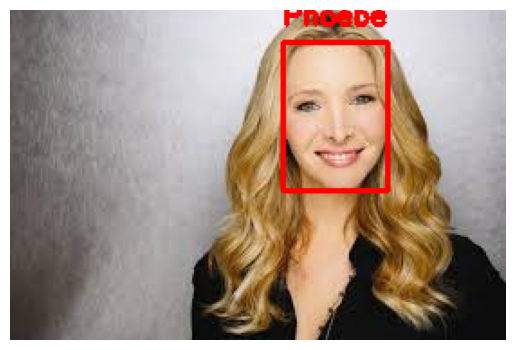

In [13]:
sample = visualize_faces(dataset.iloc[0]['path'], dataset.iloc[0]['bboxes'], [dataset.iloc[0]['person_name']])

### Задание 4: Подсчёт схожести лиц

Теперь напишем функцию, которая будет считать схожесть двух лиц по их эмбеддингам. В качестве метрик схожести возьмём L2 расстояние и косинусное расстояние, функция должна принимать на вход два эмбеддинга и параметр metric, который может принимать значения 'l2' или 'cosine'.

In [ ]:
def calculate_similarity(embedding1: np.ndarray, embedding2: np.ndarray, metric: str = 'l2') -> float:
    if metric == 'l2':
        d = (embedding1 - embedding2)
        return np.sqrt(d.dot(d))
    if metric == "cosine":
        e1 = embedding1.dot(embedding1)
        e2 = embedding2.dot(embedding2)
        return embedding1.dot(embedding2)/np.sqrt(e1*e2)
    return None

In [ ]:
sample_ch = dataset[dataset['person_name'] == 'Chandler'].iloc[0]
sample_ch1 = dataset[dataset['person_name'] == 'Chandler'].iloc[1]

sample_r = dataset[dataset['person_name'] == 'Ross'].iloc[0]
sample_m = dataset[dataset['person_name'] == 'Monica'].iloc[0]

In [ ]:
print("Similarity between Chandler and Monica:", calculate_similarity(sample_ch['embeddings'][0], sample_m['embeddings'][0], metric='cosine'))
print("Similarity between Chandler and Ross:", calculate_similarity(sample_ch['embeddings'][0], sample_r['embeddings'][0], metric='cosine'))
print("Similarity between Chandler and Chandler:", calculate_similarity(sample_ch['embeddings'][0], sample_ch1['embeddings'][0], metric='cosine'))


In [14]:
# Решение автора
def calculate_similarity(embedding1: np.ndarray, embedding2: np.ndarray, metric: str = 'l2') -> float:
    if metric == 'l2':
        return np.linalg.norm(embedding1 - embedding2)
    elif metric == 'cosine':
        return np.dot(embedding1, embedding2) / (np.linalg.norm(embedding1) * np.linalg.norm(embedding2))

### Задание 5: Поиск на групповом фото

Напишите функцию, которая будет принимать на вход наш датасет в виде датафрейма, а также путь к групповому фото. Функция должна возвращать словарь, где ключами являются имена людей на фотографии, а значениями — пара (bounding box, similarity). Гарантируется, что каждый человек встретится только единожды в рамках одной фотографии.

In [ ]:
# 1. Берём единственный эмбеддинг из списка
dataset['embedding'] = dataset['embeddings'].apply(lambda x: x[0])

# 2. Строим прототип каждого персонажа
gallery = dataset.groupby('person_name')['embedding'].apply(
    lambda x: np.mean(np.stack(x.values), axis=0)
)

gallery

In [ ]:
dict(gallery)

In [ ]:
sample_ch = dataset[dataset['person_name'] == 'Joey'].iloc[2]
ch = gallery["Chandler"]
print("Similarity between Chandler and Chandler:", calculate_similarity(sample_ch['embeddings'][0], ch, metric='cosine'))


In [ ]:
# 1. Берём единственный эмбеддинг из списка
dataset['embedding'] = dataset['embeddings'].apply(lambda x: x[0])

# 2. Строим прототип каждого персонажа
gallery = dataset.groupby('person_name')['embedding'].apply(
    lambda x: np.mean(np.stack(x.values), axis=0)
)

gallery = dict(gallery)


def process_group_photo(model: insightface.app.FaceAnalysis, dataset: pd.DataFrame, image_path: str) -> dict[str, list[np.ndarray]]:   
    img = cv2.imread(image_path)
    faces = model.get(img)
    characters, bboxes, similarity = [], [], []

    for face in faces:
        emb = face.embedding
        bbox = face.bbox.astype(np.int32)
        cosine = {key: calculate_similarity(
            emb, 
            gallery[key],
            metric='cosine') for key in gallery.keys()
                 }
        
        character = max(cosine, key=cosine.get)
        similar = cosine[character]
        
        characters.append(character)
        bboxes.append(bbox)
        similarity.append(similar)
        
    return characters, bboxes, similarity


In [ ]:
image_path = "/kaggle/input/datasets/amiralikalbasi/images-of-friends-character-for-face-recognition/Friends/Test/all (1).jpeg"
process_group_photo(model, dataset, image_path)

In [ ]:
test_dir = os.path.join(dir_path, "Test")
test_dataset = []
for sample in os.listdir(test_dir):
    test_dataset.append({'photo_path': os.path.join(test_dir, sample),
                         'characters': [],
                         'bboxes': [],
                         'similarity': []})
test_dataset = pd.DataFrame(test_dataset)
test_dataset.head()

In [ ]:
# Запроцессьте все фото в тестовой части датасета
# применяем функцию к каждой фотографии
results = test_dataset["photo_path"].apply(
    lambda p: process_group_photo(model, dataset, p)
)

# раскладываем tuple в отдельные колонки
test_dataset["characters"] = results.apply(lambda x: x[0])
test_dataset["bboxes"]     = results.apply(lambda x: x[1])
test_dataset["similarity"] = results.apply(lambda x: x[2])

test_dataset.head()

In [ ]:
test_dataset.head(50)

In [ ]:
# ручной фикс №1
idx = 41

chars = list(test_dataset.loc[idx, 'characters'])
chars[2] = 'Ross'

test_dataset.at[idx, 'characters'] = chars

In [ ]:
sample = test_dataset.iloc[41]
group_vis = visualize_faces(sample['photo_path'], [bbox for bbox in sample['bboxes']], sample['characters'])

In [ ]:
for i in [27, 29, 40]:
    chars = test_dataset.loc[i, 'characters']
    print(f'row {i}: n_faces = {len(chars)}')
    print(os.path.basename(test_dataset.loc[i, 'photo_path']))
    print(chars)
    print()

In [ ]:
# ручной фикс №2
idx = 29

test_dataset.at[idx, 'characters'] = np.array([
    'Monica',
    'Chandler',
    'Joey',
    'Phoebe',
    'Rachel'
], dtype=object)

test_dataset.at[idx, 'bboxes'] = [
    np.array([459,  79, 516, 154], dtype=np.int32),
    np.array([310,  39, 363, 110], dtype=np.int32),
    np.array([418, 113, 443, 146], dtype=np.int32),  # настоящий Joey-бокс
    np.array([ 90,  51, 144, 122], dtype=np.int32),
    np.array([516,  67, 549, 117], dtype=np.int32),  # маленький Rachel-бокс
]

sims = list(test_dataset.loc[idx, 'similarity'])[:5]
test_dataset.at[idx, 'similarity'] = sims

In [ ]:
test_dataset.loc[29].values


In [ ]:
sample = test_dataset.loc[29]
group_vis = visualize_faces(sample['photo_path'], [bbox for bbox in sample['bboxes']], sample['characters'])

In [ ]:
test_dataset.loc[29].values

In [ ]:
# ручной фикс №3
idx = 27

chars = list(test_dataset.loc[idx, 'characters'])[:4]
chars[3] = 'Monica'
sims = list(test_dataset.loc[idx, 'similarity'])[:4]

test_dataset.at[idx, 'characters'] = chars
test_dataset.at[idx, 'similarity'] = sims

test_dataset.at[idx, 'bboxes'] = [
    np.array([27, 69, 37, 81], dtype=np.int32),
    np.array([143, 81, 152, 92], dtype=np.int32),
    np.array([170, 66, 178, 75], dtype=np.int32),
    np.array([43, 85, 52, 96], dtype=np.int32),
]

In [ ]:
sample = test_dataset.loc[27]
group_vis = visualize_faces(sample['photo_path'], [bbox for bbox in sample['bboxes']], sample['characters'])

In [ ]:
test_dataset.loc[27].values


In [ ]:
# ручной фикс №4
idx = 40

chars = list(test_dataset.loc[idx, 'characters'])
chars[2] = 'Chandler'

test_dataset.at[idx, 'characters'] = chars

In [ ]:
sample = test_dataset.loc[40]
group_vis = visualize_faces(sample['photo_path'], [bbox for bbox in sample['bboxes']], sample['characters'])

In [ ]:
test_dataset.to_parquet("test_meta_5h.parquet", index=False)

In [15]:
# Решение автора
def process_group_photo(model: insightface.app.FaceAnalysis, dataset: pd.DataFrame, image_path: str) -> dict[str, list[np.ndarray]]:
    # Read and detect faces in the group photo
    annotations = extract_face_embeddings(model, image_path)
    
    # Get average embeddings for each person in dataset
    person_embeddings = {}
    for name in dataset['person_name'].unique():
        person_data = dataset[dataset['person_name'] == name]
        all_embeddings = [emb for embs in person_data['embeddings'] for emb in embs]
        if all_embeddings:
            person_embeddings[name] = np.mean(all_embeddings, axis=0)
    
    annotations['similarity'] = []
    for face in annotations['embeddings']:
        similarities = []
        for name in person_embeddings.keys():
            avg_embedding = person_embeddings[name]
            similarities.append(calculate_similarity(avg_embedding, face, metric='cosine'))
        annotations['similarity'].append(similarities)

    results = {}
    for i, bbox in enumerate(annotations['bboxes']):
        max_similarity = max(annotations['similarity'][i])
        best_match = list(person_embeddings.keys())[annotations['similarity'][i].index(max_similarity)]
        results[best_match] = (bbox, max_similarity)
    
    return results

In [16]:
test_dir = os.path.join(dir_path, "Test")
test_dataset = []
for sample in os.listdir(test_dir):
    test_dataset.append({'photo_path': os.path.join(test_dir, sample),
                         'characters': [],
                         'bboxes': [],
                         'similarity': []})
test_dataset = pd.DataFrame(test_dataset)
test_dataset.head()

,photo_path,characters,bboxes,similarity
0,/kaggle/input/datasets/amiralikalbasi/images-o...,[],[],[]
1,/kaggle/input/datasets/amiralikalbasi/images-o...,[],[],[]
2,/kaggle/input/datasets/amiralikalbasi/images-o...,[],[],[]
3,/kaggle/input/datasets/amiralikalbasi/images-o...,[],[],[]
4,/kaggle/input/datasets/amiralikalbasi/images-o...,[],[],[]


In [17]:
# Запроцессьте все фото в тестовой части датасета
results = test_dataset["photo_path"].apply(
    lambda p: process_group_photo(model, dataset, p)
)

# # раскладываем tuple в отдельные колонки
test_dataset["characters"] = results.apply(lambda x: list(x.keys()))
test_dataset["bboxes"]     = results.apply(lambda x: [box for (box, sims) in x.values()])
test_dataset["similarity"] = results.apply(lambda x: [sims for (box, sims) in x.values()])

test_dataset.head(50)

,photo_path,characters,bboxes,similarity
0,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Monica, Phoebe, Joey, Ross, Rachel, Chandler]","[[274, 98, 300, 135], [127, 79, 157, 122], [17...","[0.6408049, 0.6239615, 0.7061172, 0.8374343, 0..."
1,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Joey, Chandler]","[[276, 69, 381, 206], [604, 39, 707, 180]]","[0.6991809, 0.618825]"
2,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Chandler, Phoebe]","[[635, 512, 798, 726], [1104, 158, 1300, 433]]","[0.72961795, 0.7848718]"
3,/kaggle/input/datasets/amiralikalbasi/images-o...,[Chandler],"[[390, 152, 590, 436]]",[0.7786389]
4,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Phoebe, Rachel, Joey, Ross, Monica, Chandler]","[[681, 437, 819, 620], [881, 372, 1012, 557], ...","[0.8216904, 0.72219, 0.8588889, 0.88013405, 0...."
5,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Joey, Chandler, Ross]","[[104, 75, 166, 158], [201, 87, 256, 164], [29...","[0.85859346, 0.7275471, 0.75249696]"
6,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Ross, Phoebe, Rachel, Monica, Chandler, Joey]","[[385, 10, 504, 167], [376, 217, 489, 365], [5...","[0.8402061, 0.74006903, 0.6614864, 0.70046735,..."
7,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Chandler, Monica, Rachel, Ross, Phoebe]","[[714, 117, 971, 460], [20, 174, 320, 575], [1...","[0.7539031, 0.8241033, 0.74749625, 0.8565964, ..."
8,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Ross, Phoebe, Joey, Chandler, Rachel, Monica]","[[1068, 269, 1169, 414], [166, 267, 263, 400],...","[0.8058404, 0.75352764, 0.8037889, 0.7444724, ..."
9,/kaggle/input/datasets/amiralikalbasi/images-o...,"[Chandler, Ross, Joey]","[[294, 122, 349, 201], [176, 86, 231, 165], [3...","[0.707747, 0.77810144, 0.7716685]"


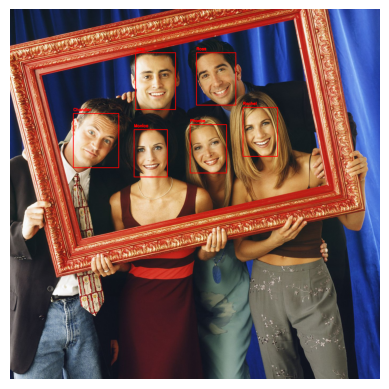

In [19]:
sample = test_dataset.loc[4]
group_vis = visualize_faces(sample['photo_path'], [bbox for bbox in sample['bboxes']], sample['characters'])

In [43]:
test_dataset.to_parquet("test_meta_author.parquet", index=False)

Загрузите parquet в LMS.

### Задание 6: Подсчёт метрики mAP

Напишем функцию для подсчёта метрики mAP на групповом фото, функция должна принимать на вход словарь с предсказаниями и словарь с gt.

In [20]:
def calculate_iou(box1, box2):
    """
    Рассчитывает IoU между двумя bbox.

    :param box1: Координаты первого bbox в формате (xmin, ymin, xmax, ymax).
    :param box2: Координаты второго bbox в формате (xmin, ymin, xmax, ymax).
    :return: Значение IoU от 0 до 1.
    """
    # Определение координат пересечения
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Если пересечения нет, IoU равно 0
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # Вычисление площади пересечения
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Вычисление площади каждого прямоугольника
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Вычисление площади объединения
    union_area = box1_area + box2_area - intersection_area

    # Вычисление IoU
    iou = intersection_area / union_area

    return iou

In [25]:
def calculate_map(predictions: dict[str, tuple[np.ndarray, float]], targets: dict[str, np.ndarray]) -> float:
    
    pred_list = sorted(
        [(name, bbox, score) for name, (bbox, score) in predictions.items()],
        key=lambda x: x[2],
        reverse=True
    )

    gt_used = {name: False for name in targets}

    tp = np.zeros(len(pred_list))
    fp = np.zeros(len(pred_list))

    for i, (name, bbox, score) in enumerate(pred_list):

        if name not in targets:
            fp[i] = 1
            continue

        if gt_used[name]:
            fp[i] = 1
            continue

        iou = calculate_iou(bbox, targets[name])

        if iou >= 0.5:
            tp[i] = 1
            gt_used[name] = True
        else:
            fp[i] = 1

    tp = np.cumsum(tp)
    fp = np.cumsum(fp)

    precision = tp / (tp + fp)

    return precision.mean()
    

In [ ]:
sample = test_dataset.loc[4]


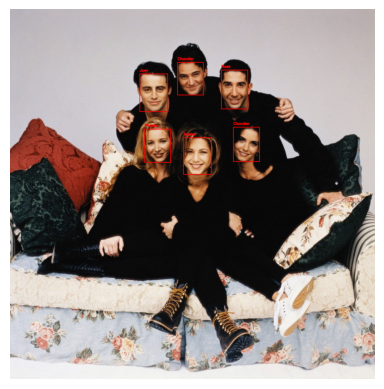

0.9111111111111111


In [50]:
sample = test_dataset.iloc[39]

true_bboxes = (np.array([541, 270, 657, 427]),
    np.array([881, 254, 991, 416]),
    np.array([723, 536, 839, 689]),
    np.array([561, 500, 669, 639]),
    np.array([698, 222, 806, 358]),
    np.array([ 931,  492, 1040,  635]))

true_characters = ['Joey', 'Ross', 'Rachel', 'Phoebe', 'Chandler', 'Monica']

ap = calculate_map({name: (bbox, 1) for name, bbox in zip(sample['characters'], sample['bboxes'])}, {name: bbox for name, bbox in zip(true_characters, true_bboxes)})

group_vis = visualize_faces(sample['photo_path'], true_bboxes, true_characters)

print(ap)

In [ ]:
# Решение автора
def calculate_map(predictions: dict[str, tuple[np.ndarray, float]], targets: dict[str, np.ndarray]) -> float:
    def calculate_iou(box1, box2):
        # Calculate intersection over union of two bounding boxes
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1]) 
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])
        
        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union = area1 + area2 - intersection
        
        return intersection / union if union > 0 else 0

    # Convert predictions to list of (name, bbox, confidence) sorted by confidence
    pred_list = [(name, bbox, conf) for name, (bbox, conf) in predictions.items()]
    pred_list.sort(key=lambda x: x[2], reverse=True)
    
    # Track matches to avoid double-counting
    matched_targets = set()
    
    # Calculate precision at each point
    precisions = []
    num_correct = 0
    
    for i, (pred_name, pred_bbox, _) in enumerate(pred_list, 1):
        # Check if predicted person exists in targets
        if pred_name in targets:
            target_bbox = targets[pred_name]
            
            # Calculate IoU with target bbox
            iou = calculate_iou(pred_bbox, target_bbox)
            
            # Consider it a match if IoU > 0.5 and target not already matched
            if iou > 0.5 and pred_name not in matched_targets:
                num_correct += 1
                matched_targets.add(pred_name)
                
        precision = num_correct / i
        precisions.append(precision)
    
    # Calculate average precision
    ap = sum(precisions) / len(precisions) if precisions else 0
    
    return ap

Загрузите в LMS код функции, а также `test_meta.parquet` из прошлого задания.

### Заключение

Отлично! В этом домашнем задании мы сделали простую систему распознавания лиц и с помощью неё обработали групповые фото — обнаружили на них лица из «базы данных», которую построили на основе одиночных фото.